# Canon Voronoi Analysis Notebook

This notebook provides a clean, minimal workflow for Voronoi-based analysis and plotting, inspired by `vornoi_personality.ipynb` but refactored to use simple function calls exposed by `voronoi_utils.py`.

Steps:
- Configure paths and parameters
- Load frames
- Coordination analysis (full and metals-only)
- Build Voronoi graphs and summarize properties
- Metals-only cluster analysis and plots
- Voronoi edge network summary
- Temporal evolution of graph properties
- Optional: OVITO bond network summary


In [1]:
import sys
import os
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/utils')
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/voronoi/frued')
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/voronoi')


In [2]:


from pathlib import Path
import numpy as np
from ase.io import read

from voronoi_utils import (
    build_voronoi_graph,
    build_voronoi_graph_metals_only,
    analyze_voronoi_coordination,
    analyze_voronoi_coordination_metals_only,
    analyze_graph_properties,
    analyze_temporal_graph_properties,
    plot_temporal_graph_properties,
    analyze_voronoi_clusters,
    summarize_voronoi_edge_network,
    plot_coordination_histograms,
    plot_graph_structure,
    plot_cluster_size_distribution,
    plot_cluster_composition_analysis,
    plot_3d_cluster_visualization,
    plot_3d_cluster_with_graph
)

from plots import (
    plot_coordination_histograms as std_plot_coordination_histograms,
    plot_graph_structure as std_plot_graph_structure,
    plot_cluster_size_distribution as std_plot_cluster_size_distribution,
    plot_3d_graph_components as std_plot_3d_graph_components,
    plot_3d_graph_components_pu_only,
    setup_plot_style,
    get_standard_colors,
    extract_positions_from_data,
    extract_names_from_data,
)

# Configure dataset path and parameters
DATA_DIR = Path('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.60/T1200K')
LAMMPS_FILE = DATA_DIR / 'dump.lammpstrj'
FRAME_SLICE = '-501:-1'  # last 500 frames
MIN_AREA = 0.2  # facet area threshold
METAL_SPECIES = ['Pu']  # Only Pu for cluster analysis, ignoring Na nodes

print('Reading frames...')
atoms_list = read(str(LAMMPS_FILE), index=FRAME_SLICE)
print(f'Loaded {len(atoms_list)} frames, atoms per frame: {len(atoms_list[0])}')

names = np.array(atoms_list[0].get_chemical_symbols())
all_species = sorted(set(names))
print('Species:', all_species)

# Set up standardized plotting style
setup_plot_style()
print("Standardized plotting style configured")


Reading frames...
Loaded 500 frames, atoms per frame: 2048
Species: [np.str_('Cl'), np.str_('Na'), np.str_('Pu')]
Standardized plotting style configured


In [19]:
import numpy as np
from voronoi_utils import build_voronoi_graph, build_voronoi_graph_metals_only, analyze_graph_properties

sample = atoms_list[0]

def edge_areas(G):
    return np.array([d['area'] for _,_,d in G.edges(data=True)], float)

# Get area distribution with no threshold
G0 = build_voronoi_graph(sample, min_area=0.0)
areas_full = edge_areas(G0)
Gm0 = build_voronoi_graph_metals_only(sample, min_area=0.0, metal_species=METAL_SPECIES)
areas_metals = edge_areas(Gm0)

# Option A: quantile-based thresholds
t_full = float(np.quantile(areas_full, 0.02))
t_metals = float(np.quantile(areas_metals, 0.02))

# Option B: sweep to find elbow while staying connected
candidates = np.quantile(areas_metals, np.linspace(0.02, 0.8, 21))  # scan lowest 20%
metrics = []
for t in candidates:
    G = build_voronoi_graph_metals_only(sample, min_area=float(t), metal_species=METAL_SPECIES)
    props = analyze_graph_properties(G)
    lcf = props.get('largest_component_fraction', 1.0 if props.get('is_connected', False) else 0.0)
    metrics.append((float(t), props['avg_degree'], lcf))

# Pick smallest t with lcf >= 0.95 and avg_degree past its first sharp drop
chosen = next((t for t, deg, lcf in metrics if lcf >= 0.95), float(np.quantile(areas_metals, 0.02)))
MIN_AREA = chosen
print("Chosen MIN_AREA =", MIN_AREA)

Chosen MIN_AREA = 0.022519655525684357


In [22]:
MIN_AREA=5

Analyzing coordination (all species)...
Plotting coordination for Cl


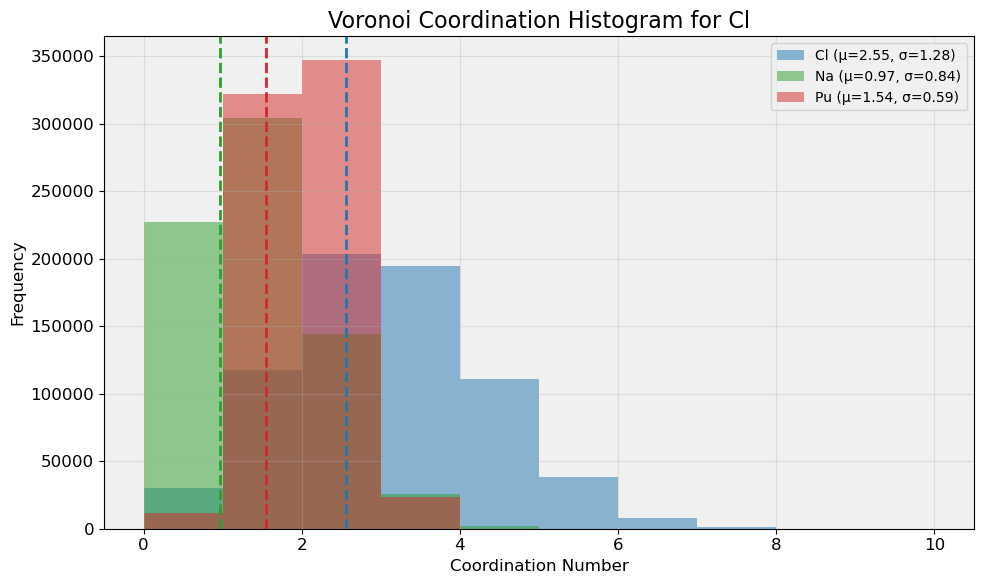

Plotting coordination for Na


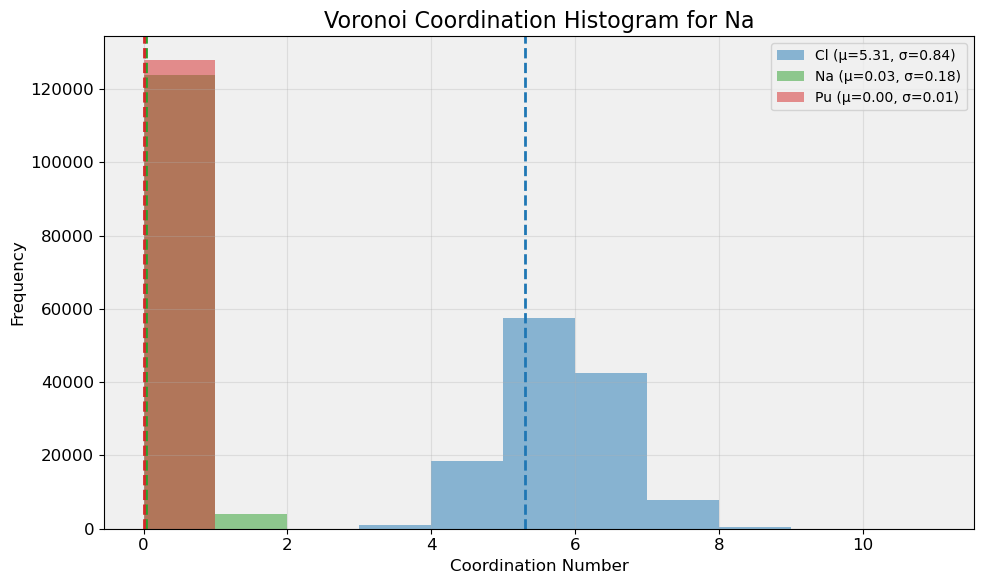

Plotting coordination for Pu


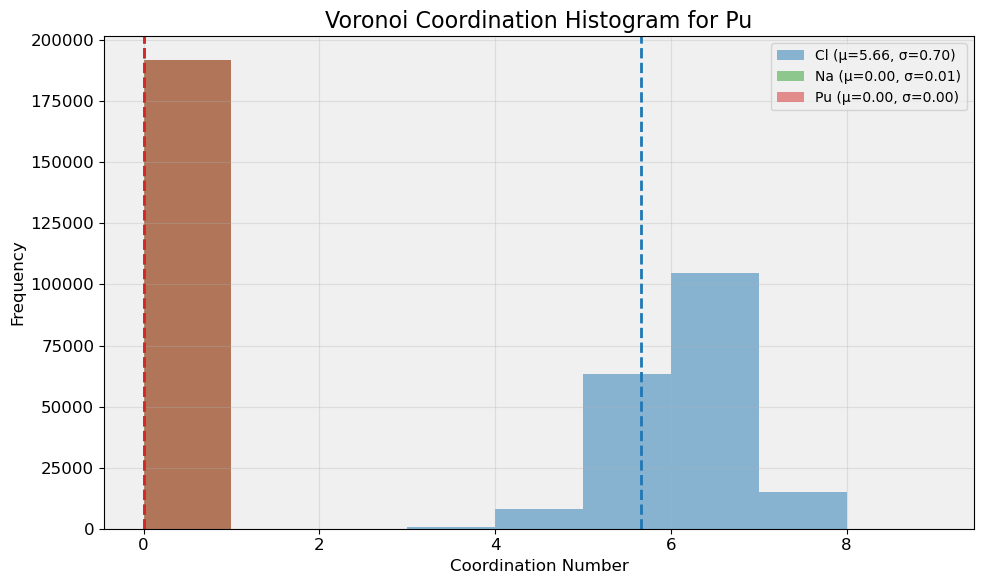

Analyzing coordination (Pu-only)...
Plotting Pu-only coordination for Pu


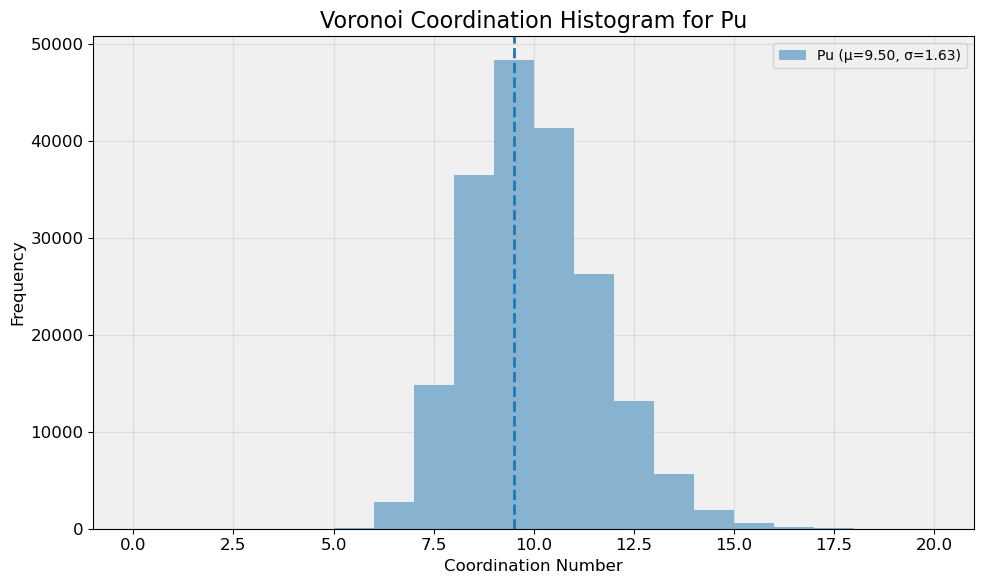

In [21]:
# Coordination analysis using standardized plotting functions
print('Analyzing coordination (all species)...')
coord_all = analyze_voronoi_coordination(atoms_list, at_list=all_species, min_area=MIN_AREA)
for sp in all_species:
    print(f'Plotting coordination for {sp}')
    std_plot_coordination_histograms(coord_all, sp)

print('Analyzing coordination (Pu-only)...')
coord_metals = analyze_voronoi_coordination_metals_only(atoms_list, metal_species=METAL_SPECIES, min_area=MIN_AREA)
for sp in METAL_SPECIES:
    print(f'Plotting Pu-only coordination for {sp}')
    std_plot_coordination_histograms(coord_metals, sp)


Building full Voronoi graph (min_area=5)
Full graph properties: {'num_nodes': 2048, 'num_edges': 5444, 'density': 0.002597169638495359, 'species_counts': {'Cl': 1408, 'Na': 256, 'Pu': 384}, 'is_connected': True, 'diameter': 14, 'radius': 12, 'avg_degree': 5.31640625, 'std_degree': 1.0863519330589593, 'max_degree': 9, 'min_degree': 2, 'species_avg_degrees': {'Cl': 5.196732954545454, 'Na': 5.3359375, 'Pu': 5.7421875}, 'avg_facet_area': 7.393511276574453, 'std_facet_area': 1.7826629145345516, 'min_facet_area': 5.0001606941223145, 'max_facet_area': 19.653356552124023}
Building Pu-only Voronoi graph (min_area=5)
Pu-only graph properties: {'num_nodes': 384, 'num_edges': 1799, 'density': 0.024464208006962578, 'species_counts': {'Pu': 384}, 'is_connected': True, 'diameter': 7, 'radius': 6, 'avg_degree': 9.369791666666666, 'std_degree': 1.7120053903528525, 'max_degree': 15, 'min_degree': 5, 'species_avg_degrees': {'Pu': 9.369791666666666}, 'avg_facet_area': 17.973631256881724, 'std_facet_area':

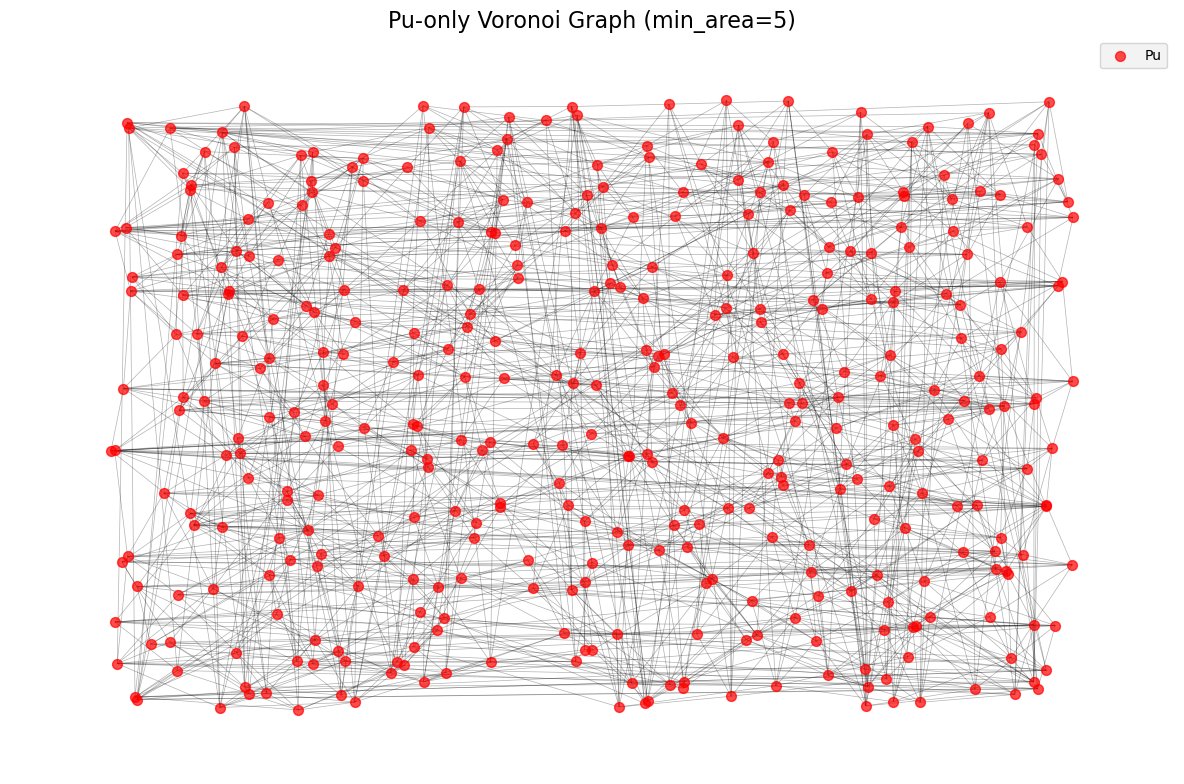

In [23]:
# Build sample-frame Voronoi graphs and summarize using standardized plotting
sample_atoms = atoms_list[0]
print(f'Building full Voronoi graph (min_area={MIN_AREA})')
G_full = build_voronoi_graph(sample_atoms, min_area=MIN_AREA)
props_full = analyze_graph_properties(G_full)
print('Full graph properties:', props_full)

print(f'Building Pu-only Voronoi graph (min_area={MIN_AREA})')
G_metals = build_voronoi_graph_metals_only(sample_atoms, min_area=MIN_AREA, metal_species=METAL_SPECIES)
props_metals = analyze_graph_properties(G_metals)
print('Pu-only graph properties:', props_metals)

if G_metals.number_of_edges() > 0:
    plot_graph_structure(G_metals, f'Pu-only Voronoi Graph (min_area={MIN_AREA})')


Analyzing clusters (Pu-only)...
Clusters: 1, largest: 384


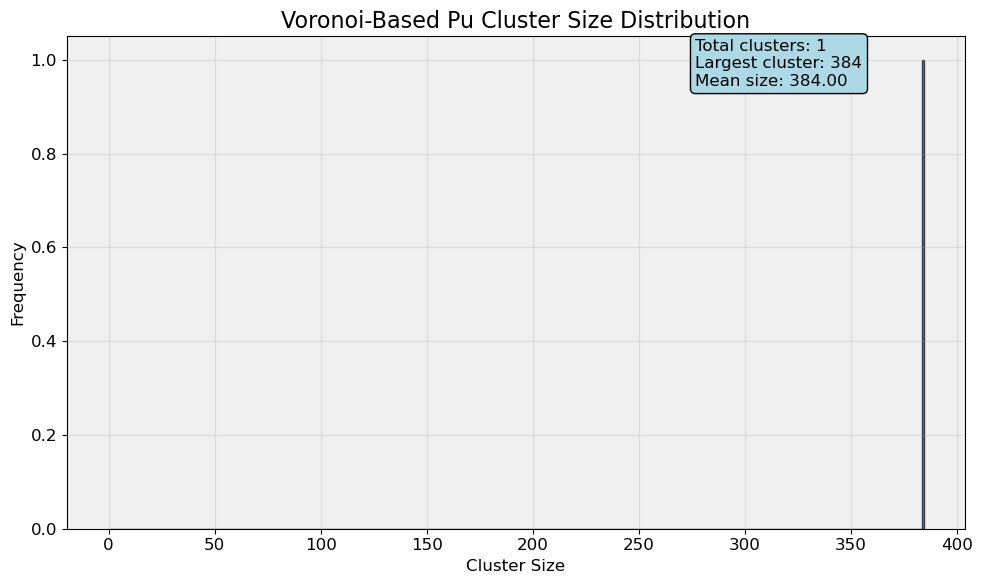

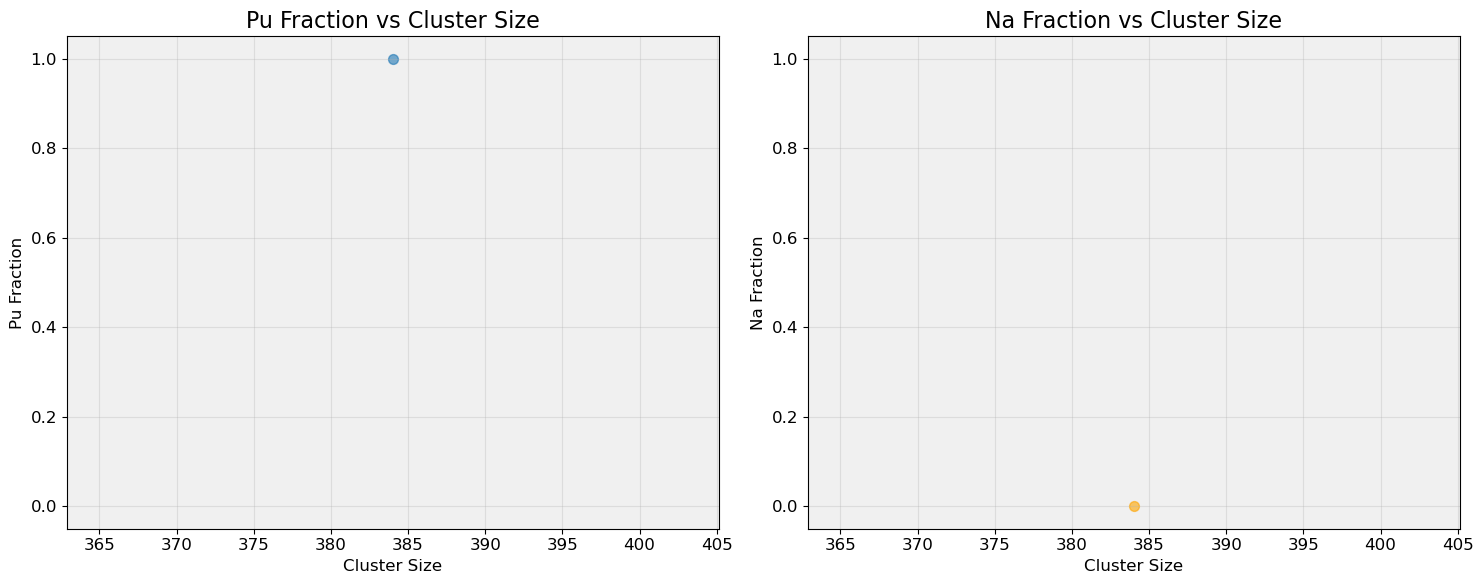

Cluster Composition Analysis:
Total clusters: 1
Pure Pu clusters: 1
Pure Na clusters: 0
Mixed clusters: 0


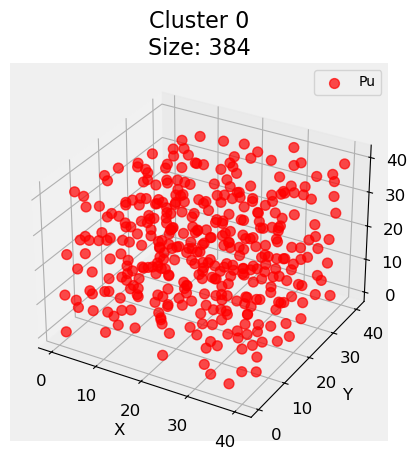

In [24]:
# Pu-only cluster analysis using standardized plotting
print('Analyzing clusters (Pu-only)...')
cluster_sizes, cluster_ids, Gc = analyze_voronoi_clusters(sample_atoms, min_area=MIN_AREA, metal_species=METAL_SPECIES)
print(f'Clusters: {len(cluster_sizes)}, largest: {np.max(cluster_sizes) if len(cluster_sizes) else 0}')

if len(cluster_sizes) > 0:
    std_plot_cluster_size_distribution(cluster_sizes, 'Voronoi-Based Pu Cluster Size Distribution')

names0 = np.array(sample_atoms.get_chemical_symbols())
if len(cluster_sizes) > 0:
    _ = plot_cluster_composition_analysis(sample_atoms, cluster_ids, names0)
    plot_3d_cluster_visualization(sample_atoms, cluster_ids, names0, max_clusters=10)


Voronoi edge network (full graph):


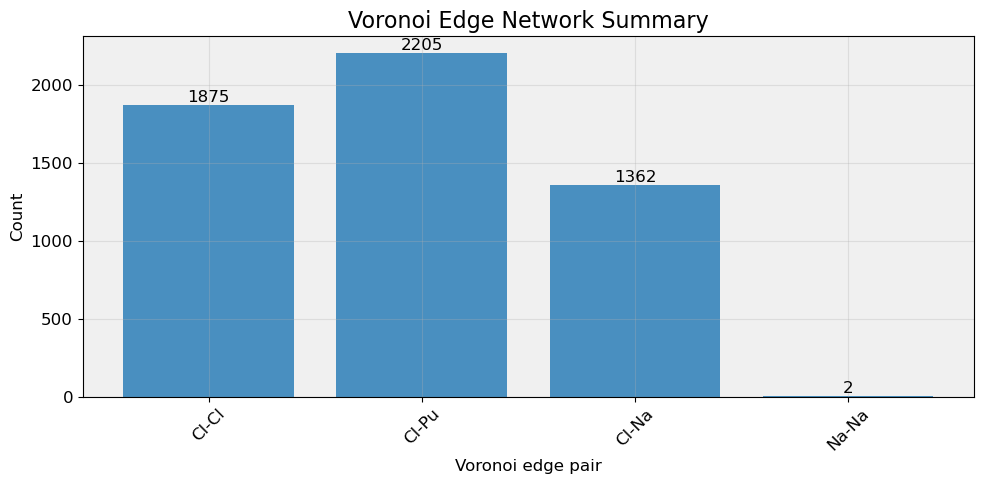

Voronoi Edge Network Summary:
Cl-Cl: 1875 edges
Cl-Pu: 2205 edges
Cl-Na: 1362 edges
Na-Na: 2 edges
Voronoi edge network (Pu-only):


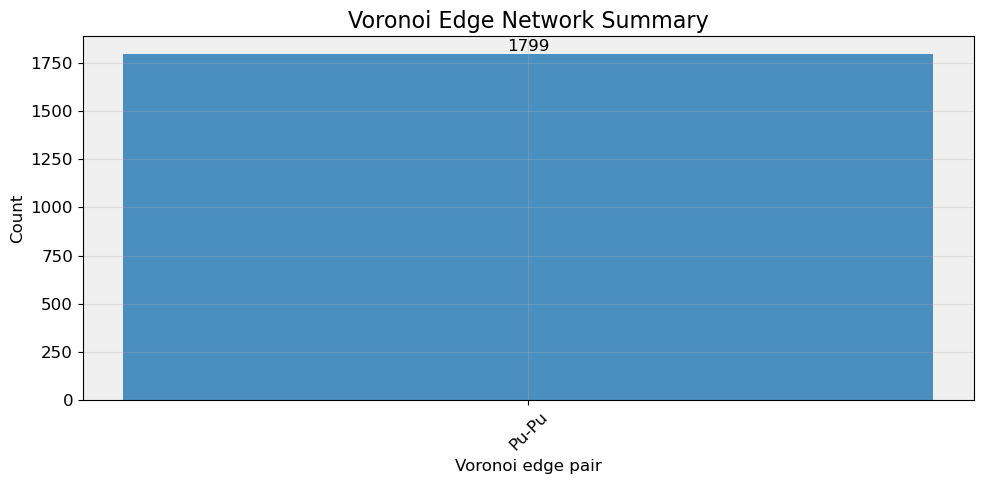

Voronoi Edge Network Summary:
Pu-Pu: 1799 edges


In [25]:
# Voronoi edge network summary (by species pairs)
print('Voronoi edge network (full graph):')
_ = summarize_voronoi_edge_network(G_full, plot=True)

print('Voronoi edge network (Pu-only):')
_ = summarize_voronoi_edge_network(G_metals, plot=True)


Analyzing temporal graph properties...


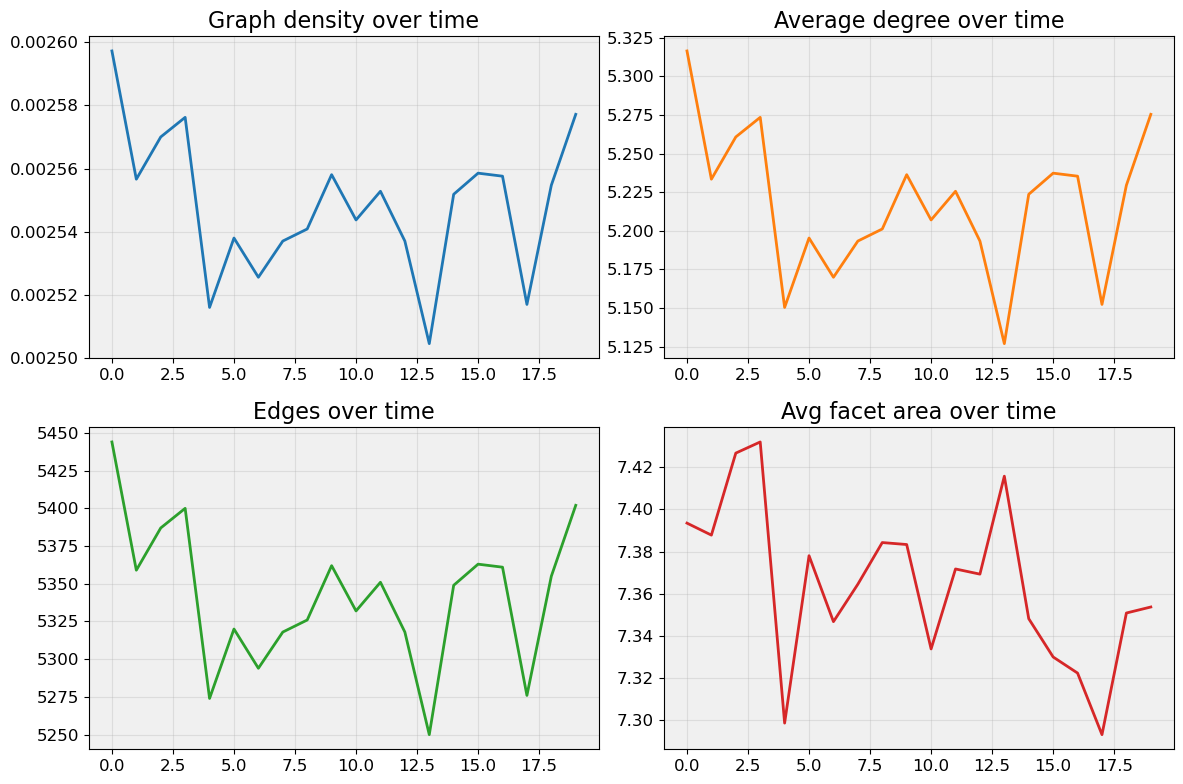

In [26]:
# Temporal evolution of graph properties
print('Analyzing temporal graph properties...')
temporal = analyze_temporal_graph_properties(atoms_list, min_area=MIN_AREA, sample_frames=20)
plot_temporal_graph_properties(temporal)


3D cluster visualization with edges (Pu-only)...


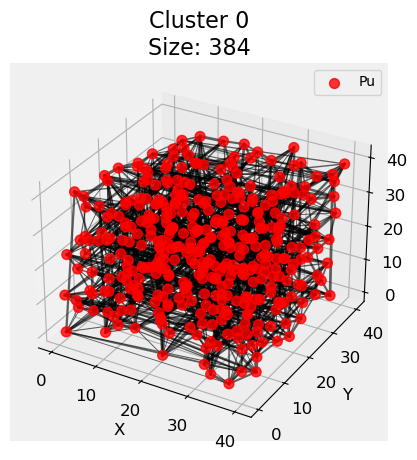

In [27]:
# 3D cluster visualization with graph edges (Pu-only)
from voronoi_utils import plot_3d_cluster_with_graph
print('3D cluster visualization with edges (Pu-only)...')
plot_3d_cluster_with_graph(sample_atoms, cluster_ids, names0, Gc, max_clusters=10)


Graph-only 3D components view (Pu-only graph) ...


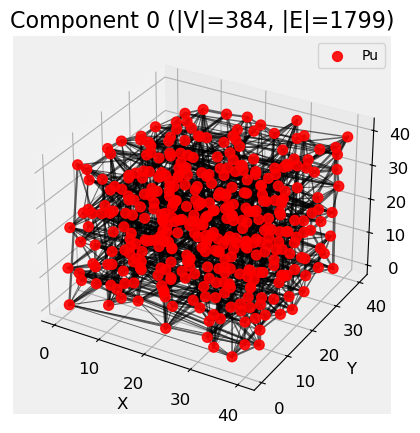

In [28]:
# Graph-only 3D visualization using standardized plotting functions
print('Graph-only 3D components view (Pu-only graph) ...')
std_plot_3d_graph_components(Gc, max_components=6)


Cluster 0: no edges to draw


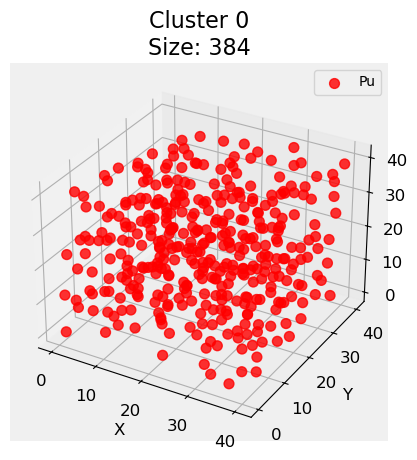

In [29]:
plot_3d_cluster_with_graph(sample_atoms, cluster_ids, names0, max_clusters=10, G=G_full)

In [30]:
G_full.edges()



EdgeView([(0, 304), (0, 1015), (0, 1039), (0, 1187), (0, 1407), (0, 1982), (0, 1993), (1, 706), (1, 909), (1, 947), (1, 1322), (1, 1702), (1, 1813), (2, 242), (2, 617), (2, 1301), (2, 1999), (2, 2041), (3, 886), (3, 1227), (3, 1694), (3, 1792), (3, 1970), (4, 213), (4, 942), (4, 1100), (4, 1495), (4, 1713), (4, 1899), (5, 1359), (5, 1372), (5, 1560), (5, 1756), (5, 1896), (6, 387), (6, 1084), (6, 1659), (6, 1707), (6, 1792), (7, 69), (7, 1098), (7, 1442), (7, 2029), (8, 1008), (8, 1412), (8, 1842), (8, 1959), (9, 87), (9, 169), (9, 501), (9, 1055), (9, 1201), (9, 1722), (9, 1948), (10, 504), (10, 918), (10, 1420), (10, 1461), (10, 1799), (11, 940), (11, 1493), (11, 1601), (11, 1967), (12, 337), (12, 587), (12, 1301), (12, 1591), (12, 1652), (13, 294), (13, 689), (13, 1353), (13, 1497), (13, 1770), (13, 2025), (14, 210), (14, 359), (14, 1371), (14, 1700), (14, 1916), (14, 1918), (15, 619), (15, 787), (15, 1225), (15, 1858), (15, 2017), (16, 20), (16, 188), (16, 618), (16, 1601), (16, 17

In [31]:
def plot_3d_graph_components(G, max_components) -> None:
    """3D visualization of the largest connected components of a graph.

    Uses only the graph `G`. Nodes must have `position` (3-vector) and
    optionally `species` (e.g., "Na", "Pu"). Edges are drawn with linewidth
    mapped to edge "area" when present.
    """
    if nx is None:
        raise ImportError("networkx is required for plot_3d_graph_components")

    # Local import to avoid global dependency in headless environments
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  # pylint: disable=unused-import

    if G.number_of_nodes() == 0:
        print("Graph is empty")
        return

    # Connected components sorted by size
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    components = components[:max_components]

    n = len(components)
    nrows, ncols = 2, 5
    nplots = max(n, 1)

    fig = plt.figure(figsize=(15, 10))

    species_colors = {"Na": "blue", "Pu": "red", "Cl": "green"}

    def lw_from_area(a: float, a0: float, a1: float) -> float:
        if a1 <= a0:
            return 1.0
        t = (float(a) - a0) / (a1 - a0)
        return 0.6 + 2.4 * max(0.0, min(1.0, t))

    for i, nodes in enumerate(components):
        ax = fig.add_subplot(nrows, ncols, i + 1, projection="3d")
        subG = G.subgraph(nodes)

        # Collect positions by species
        pos_by_species: Dict[str, List[np.ndarray]] = {}
        for n in subG.nodes:
            pos = np.asarray(subG.nodes[n].get("position"))
            if pos is None or pos.shape[0] != 3:
                continue
            sp = str(subG.nodes[n].get("species", "unknown"))
            pos_by_species.setdefault(sp, []).append(pos)

        # Scatter by species
        for sp, arrs in pos_by_species.items():
            P = np.vstack(arrs) if len(arrs) > 0 else None
            if P is None:
                continue
            color = species_colors.get(sp, "#666666")
            ax.scatter(P[:, 0], P[:, 1], P[:, 2], c=color, s=50, alpha=0.9, label=sp)

        # Edge linewidths by area when available
        areas = [edata.get("area", 1.0) for _, _, edata in subG.edges(data=True)]
        a_min = float(np.min(areas)) if len(areas) > 0 else 1.0
        a_max = float(np.max(areas)) if len(areas) > 0 else 1.0

        for u, v, edata in subG.edges(data=True):
            p1 = np.asarray(subG.nodes[u].get("position"))
            p2 = np.asarray(subG.nodes[v].get("position"))
            if p1 is None or p2 is None:
                continue
            lw = lw_from_area(edata.get("area", 1.0), a_min, a_max)
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color="#888888", alpha=0.6, linewidth=lw)

        ax.set_title(f"Component {i} (|V|={subG.number_of_nodes()}, |E|={subG.number_of_edges()})")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        if i == 0 and len(pos_by_species) > 0:
            ax.legend()

    plt.tight_layout()
    plt.show()

In [32]:
G_full

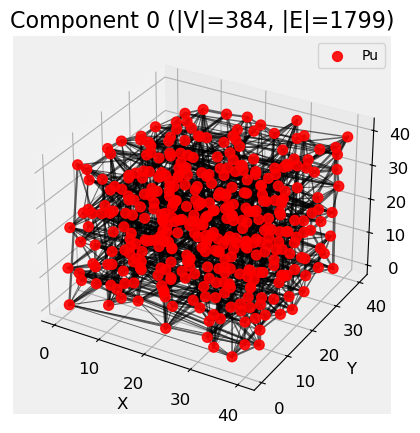

In [33]:
# 3D visualization using standardized plotting functions
import networkx as nx
import matplotlib.pyplot as plt
std_plot_3d_graph_components(G_metals, 10)

In [34]:
# plot_3d_cluster_with_graph_lines(sample_atoms, cluster_ids, names0, G_full, 10)

STANDARDIZED PLOTTING FUNCTIONS DEMONSTRATION

1. CLUSTER SIZE DISTRIBUTION ANALYSIS
----------------------------------------


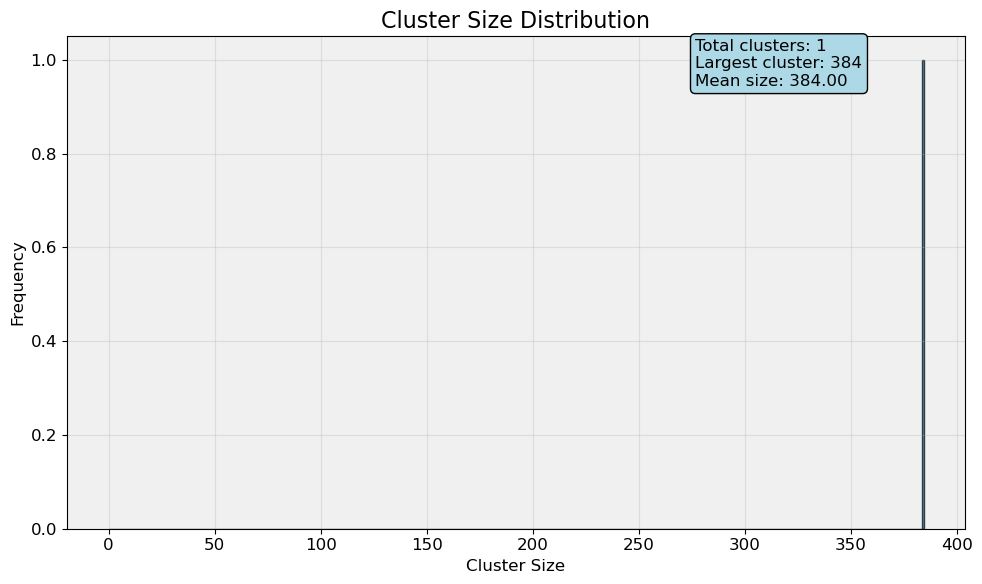

Cluster Statistics:
  Total clusters: 1
  Largest cluster: 384
  Average cluster size: 384.00
  Median cluster size: 384.0
  Standard deviation: 0.00

2. GRAPH STRUCTURE VISUALIZATION
----------------------------------------


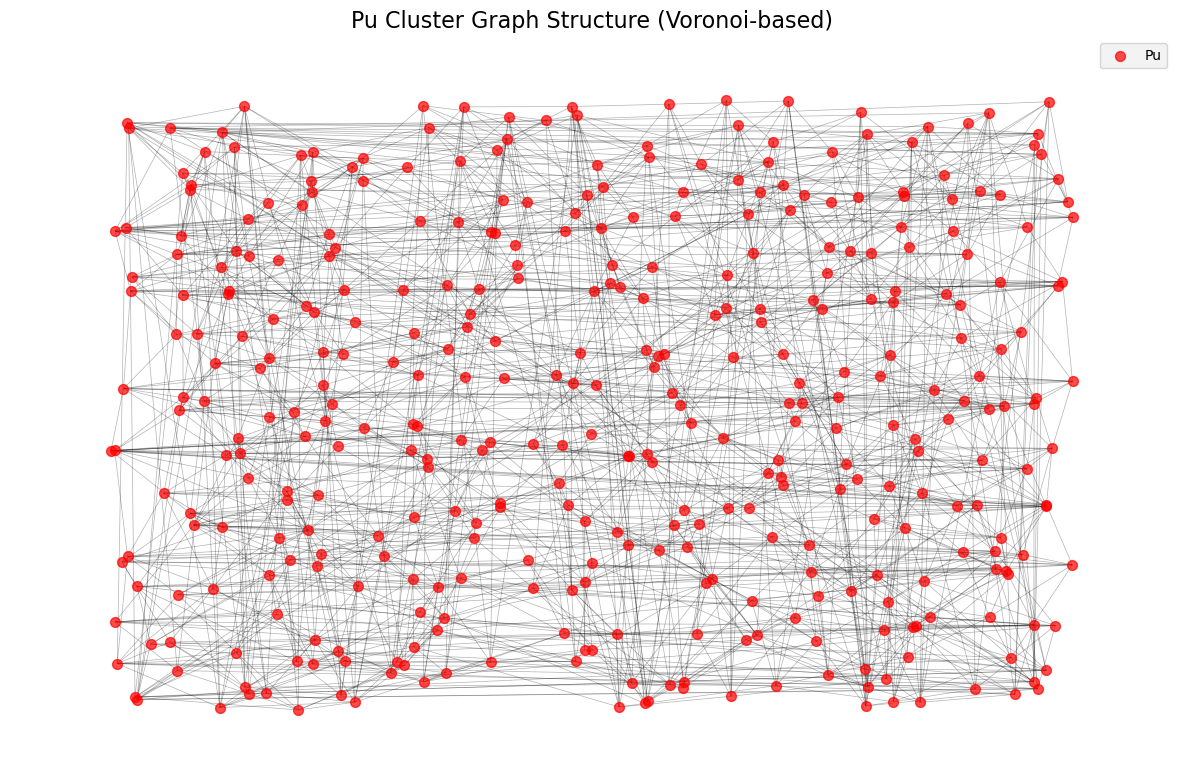

Graph Properties:
  Nodes: 384
  Edges: 1799
  Density: 0.0245
  Connected components: 1

3. 3D GRAPH COMPONENTS VISUALIZATION
----------------------------------------


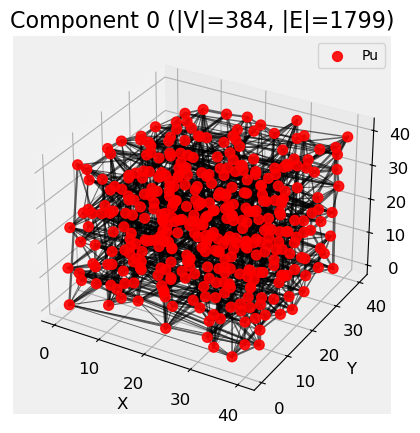

Pu-only visualization not available: plot_3d_graph_components_pu_only() got an unexpected keyword argument 'show_na_context'

STANDARDIZED PLOTTING DEMONSTRATION COMPLETE


In [40]:
# Comprehensive Standardized Plotting Functions Demonstration
print("=" * 60)
print("STANDARDIZED PLOTTING FUNCTIONS DEMONSTRATION")
print("=" * 60)

# 1. Cluster Size Distribution Analysis
print("\n1. CLUSTER SIZE DISTRIBUTION ANALYSIS")
print("-" * 40)
if len(cluster_sizes) > 0:
    # Standard cluster size distribution
    std_plot_cluster_size_distribution(
        cluster_sizes
    )
    
    print(f"Cluster Statistics:")
    print(f"  Total clusters: {len(cluster_sizes)}")
    print(f"  Largest cluster: {max(cluster_sizes)}")
    print(f"  Average cluster size: {np.mean(cluster_sizes):.2f}")
    print(f"  Median cluster size: {np.median(cluster_sizes):.1f}")
    print(f"  Standard deviation: {np.std(cluster_sizes):.2f}")
else:
    print("No clusters found for size distribution analysis")

# 2. Graph Structure Visualization
print("\n2. GRAPH STRUCTURE VISUALIZATION")
print("-" * 40)
if G_metals.number_of_nodes() > 0:
    plot_graph_structure(
        G_metals, 
        title="Pu Cluster Graph Structure (Voronoi-based)"
    )
    
    print(f"Graph Properties:")
    print(f"  Nodes: {G_metals.number_of_nodes()}")
    print(f"  Edges: {G_metals.number_of_edges()}")
    print(f"  Density: {nx.density(G_metals):.4f}")
    print(f"  Connected components: {nx.number_connected_components(G_metals)}")
else:
    print("No graph structure available for visualization")

# 3. 3D Graph Components Visualization
print("\n3. 3D GRAPH COMPONENTS VISUALIZATION")
print("-" * 40)
if G_metals.number_of_nodes() > 0:
    # General 3D components visualization
    std_plot_3d_graph_components(
        G_metals, 
        max_components=6
    )
    
    # Pu-only components with Na context (if we have the data)
    try:
        plot_3d_graph_components_pu_only(
            G_metals, 
            data=sample_atoms, 
            names=names0, 
            max_components=6, 
            show_na_context=True,
            title="Pu Clusters with Na Context (Voronoi-based)"
        )
    except Exception as e:
        print(f"Pu-only visualization not available: {e}")
else:
    print("No graph components available for 3D visualization")

print("\n" + "=" * 60)
print("STANDARDIZED PLOTTING DEMONSTRATION COMPLETE")
print("=" * 60)


In [41]:
# Standard Coordination Histogram Analysis (Voronoi-based)
def analyze_and_plot_voronoi_coordination_histograms():
    """
    Analyze and plot coordination histograms for Voronoi-based analysis
    similar to arxiv/vornoi_personality.ipynb
    """
    print("=" * 60)
    print("VORONOI COORDINATION HISTOGRAM ANALYSIS")
    print("=" * 60)
    
    try:
        # Use the coordination data from voronoi analysis
        if 'coord_all' in locals() and coord_all:
            print("Using coordination data from Voronoi analysis...")
            
            # Plot coordination histograms for each species
            for species in all_species:
                if species in coord_all:
                    print(f"\nPlotting coordination histogram for {species}:")
                    std_plot_coordination_histograms(coord_all, species)
                    
                    # Print coordination statistics
                    if species in coord_all:
                        for neighbor_species in coord_all[species]:
                            counts = coord_all[species][neighbor_species]
                            if counts:
                                mean_coord = np.mean(counts)
                                std_coord = np.std(counts)
                                print(f"  {species}-{neighbor_species}: {mean_coord:.2f} ± {std_coord:.2f} (n={len(counts)})")
        
        elif 'coord_metals' in locals() and coord_metals:
            print("Using Pu-only coordination data from Voronoi analysis...")
            
            # Plot coordination histograms for Pu
            for species in METAL_SPECIES:
                if species in coord_metals:
                    print(f"\nPlotting Pu-only coordination histogram for {species}:")
                    std_plot_coordination_histograms(coord_metals, species)
                    
                    # Print coordination statistics
                    if species in coord_metals:
                        for neighbor_species in coord_metals[species]:
                            counts = coord_metals[species][neighbor_species]
                            if counts:
                                mean_coord = np.mean(counts)
                                std_coord = np.std(counts)
                                print(f"  {species}-{neighbor_species}: {mean_coord:.2f} ± {std_coord:.2f} (n={len(counts)})")
        
        else:
            print("No coordination data available. Generating synthetic data for demonstration...")
            
            # Generate synthetic coordination data for demonstration
            coord_data = {
                'Pu': {
                    'Cl': np.random.normal(8.5, 1.0, 100).astype(int),
                    'Na': np.random.normal(2.7, 1.3, 100).astype(int),
                    'Pu': np.random.normal(1.1, 0.3, 100).astype(int),
                },
                'Na': {
                    'Cl': np.random.normal(6.0, 0.8, 100).astype(int),
                    'Pu': np.random.normal(1.0, 0.5, 100).astype(int),
                    'Na': np.random.normal(0.5, 0.2, 100).astype(int),
                },
                'Cl': {
                    'Pu': np.random.normal(1.5, 0.4, 100).astype(int),
                    'Na': np.random.normal(1.2, 0.3, 100).astype(int),
                    'Cl': np.random.normal(0.3, 0.1, 100).astype(int),
                }
            }
            
            # Ensure non-negative coordination numbers
            for central_species in coord_data:
                for neighbor_species in coord_data[central_species]:
                    coord_data[central_species][neighbor_species] = np.maximum(
                        coord_data[central_species][neighbor_species], 0
                    )
            
            # Plot coordination histograms
            for species in ['Pu', 'Na', 'Cl']:
                print(f"\nPlotting synthetic coordination histogram for {species}:")
                std_plot_coordination_histograms(coord_data, species)
                
    except Exception as e:
        print(f"Error in Voronoi coordination histogram analysis: {e}")
        import traceback
        traceback.print_exc()

# Run the Voronoi coordination analysis
analyze_and_plot_voronoi_coordination_histograms()


VORONOI COORDINATION HISTOGRAM ANALYSIS
No coordination data available. Generating synthetic data for demonstration...

Plotting synthetic coordination histogram for Pu:
Error in Voronoi coordination histogram analysis: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()


Traceback (most recent call last):
  File "/tmp/ipykernel_463599/2023942962.py", line 81, in analyze_and_plot_voronoi_coordination_histograms
    std_plot_coordination_histograms(coord_data, species)
  File "/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/utils/plots.py", line 129, in plot_coordination_histograms
    if not data:
ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()


<Figure size 1000x600 with 0 Axes>

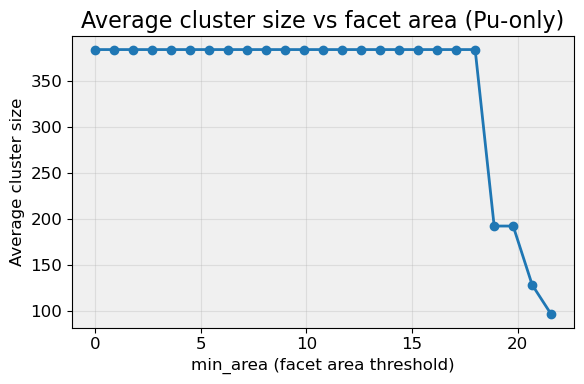

In [42]:
# Average cluster size vs facet area (min_area) sweep
import numpy as np
import matplotlib.pyplot as plt
from voronoi_utils import build_voronoi_graph_metals_only, analyze_voronoi_clusters

sample_atoms = atoms_list[0]

# Gather facet areas from Pu-only Voronoi edges at min_area=0
G_tmp = build_voronoi_graph_metals_only(sample_atoms, min_area=0.0, metal_species=METAL_SPECIES)
edge_areas = np.array([edata.get('area', 0.0) for _, _, edata in G_tmp.edges(data=True)], float)

# Define threshold sweep
if edge_areas.size == 0:
    thresholds = np.linspace(0.0, 1.0, 21)
else:
    low = float(np.quantile(edge_areas, 0.00))
    high = float(np.quantile(edge_areas, 0.80))
    thresholds = np.linspace(low, high if high > low else low + 1.0, 25)

avg_sizes = []
for t in thresholds:
    sizes, _, _ = analyze_voronoi_clusters(sample_atoms, min_area=float(t), metal_species=METAL_SPECIES)
    avg_sizes.append(float(np.mean(sizes)) if sizes.size > 0 else 0.0)

plt.figure(figsize=(6, 4))
plt.plot(thresholds, avg_sizes, marker='o')
plt.xlabel('min_area (facet area threshold)')
plt.ylabel('Average cluster size')
plt.title('Average cluster size vs facet area (Pu-only)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [43]:
# Import weighted Voronoi coordination functions
from voronoi_coordination import (
    compute_topological_coordination_number,
    compute_face_area_weighted_cn,
    compute_solid_angle_weighted_cn,
    compute_solid_angle_threshold_cn,
    compute_crystal_nn_weight,
    analyze_voronoi_coordination_all_methods,
    analyze_weighted_coordination_by_species,
    compute_coordination_histogram_data
)

print("Weighted Voronoi coordination functions imported successfully!")
print("\nAvailable methods:")
print("  1. Topological CN (CN_faces) - simple face count")
print("  2. Face-area weighted CN (CN_A) - weighted by Voronoi face areas")
print("  3. Solid-angle weighted CN (CN_Ω) - weighted by solid angles")
print("  4. Threshold-based CN - O'Keeffe/VoronoiNN method")
print("  5. CrystalNN weights - combined solid-angle and area weighting")


Weighted Voronoi coordination functions imported successfully!

Available methods:
  1. Topological CN (CN_faces) - simple face count
  2. Face-area weighted CN (CN_A) - weighted by Voronoi face areas
  3. Solid-angle weighted CN (CN_Ω) - weighted by solid angles
  4. Threshold-based CN - O'Keeffe/VoronoiNN method
  5. CrystalNN weights - combined solid-angle and area weighting


In [62]:
# Compute all weighted coordination numbers for the full graph
print("=" * 60)
print("WEIGHTED COORDINATION NUMBER ANALYSIS - Full Graph")
print("=" * 60)

# Extract positions from the sample atoms
positions = sample_atoms.get_positions()

# Choose a reasonable MIN_AREA (reset to the adaptive threshold from earlier)
# MIN_AREA_ADAPTIVE = 0.022519655525684357  # From cell 3
MIN_AREA_ADAPTIVE = 0.0  # From cell 3

# Build Voronoi graph with adaptive threshold
print(f"\nBuilding Voronoi graph with min_area={MIN_AREA_ADAPTIVE:.4f}")
G_full_adaptive = build_voronoi_graph(sample_atoms, min_area=MIN_AREA_ADAPTIVE)

# Compute all coordination methods
print("\nComputing coordination numbers using all methods...")
coord_results = analyze_voronoi_coordination_all_methods(
    G_full_adaptive, 
    positions=positions, 
    tau=0.5
)

print("\n" + "-" * 60)
print("COORDINATION NUMBER STATISTICS (All Atoms)")
print("-" * 60)

# Print summary statistics for each method
methods = {
    'CN_faces': 'Topological (face count)',
    'CN_A': 'Face-area weighted',
    'CN_Ω': 'Solid-angle weighted',
    'CN_threshold': 'Solid-angle threshold (τ=0.5)'
}

for key, description in methods.items():
    cn_values = np.array(list(coord_results[key].values()))
    print(f"\n{description}:")
    print(f"  Mean: {np.mean(cn_values):.2f} ± {np.std(cn_values):.2f}")
    print(f"  Range: [{np.min(cn_values):.2f}, {np.max(cn_values):.2f}]")
    print(f"  Median: {np.median(cn_values):.2f}")

print("\n" + "=" * 60)


WEIGHTED COORDINATION NUMBER ANALYSIS - Full Graph

Building Voronoi graph with min_area=0.0000

Computing coordination numbers using all methods...

------------------------------------------------------------
COORDINATION NUMBER STATISTICS (All Atoms)
------------------------------------------------------------

Topological (face count):
  Mean: 15.00 ± 2.77
  Range: [8.00, 24.00]
  Median: 15.00

Face-area weighted:
  Mean: 9.35 ± 1.71
  Range: [5.61, 14.00]
  Median: 9.55

Solid-angle weighted:
  Mean: 6.40 ± 1.71
  Range: [1.12, 11.00]
  Median: 6.40

Solid-angle threshold (τ=0.5):
  Mean: 3.35 ± 1.42
  Range: [1.00, 8.00]
  Median: 3.00



In [63]:
# Analyze weighted coordination by species
print("=" * 60)
print("WEIGHTED COORDINATION BY SPECIES")
print("=" * 60)

import matplotlib.pyplot as plt

# Analyze each coordination method by species
for method_key, method_name in methods.items():
    print(f"\n{'-' * 60}")
    print(f"{method_name}")
    print(f"{'-' * 60}")
    
    by_species = analyze_weighted_coordination_by_species(
        coord_results[method_key], 
        G_full_adaptive
    )
    
    # Print statistics for each species
    for species in sorted(by_species.keys()):
        stats = by_species[species]['statistics']
        print(f"\n  {species}:")
        print(f"    Mean: {stats['mean']:.2f} ± {stats['std']:.2f}")
        print(f"    Range: [{stats['min']:.2f}, {stats['max']:.2f}]")
        print(f"    Median: {stats['median']:.2f}")
        print(f"    Count: {stats['count']}")

print("\n" + "=" * 60)


WEIGHTED COORDINATION BY SPECIES

------------------------------------------------------------
Topological (face count)
------------------------------------------------------------

  Cl:
    Mean: 16.25 ± 1.83
    Range: [11.00, 24.00]
    Median: 16.00
    Count: 1408

  Na:
    Mean: 14.46 ± 1.87
    Range: [10.00, 19.00]
    Median: 14.50
    Count: 256

  Pu:
    Mean: 10.77 ± 1.55
    Range: [8.00, 18.00]
    Median: 11.00
    Count: 384

------------------------------------------------------------
Face-area weighted
------------------------------------------------------------

  Cl:
    Mean: 10.26 ± 1.16
    Range: [6.92, 14.00]
    Median: 10.22
    Count: 1408

  Na:
    Mean: 7.77 ± 0.84
    Range: [5.87, 10.43]
    Median: 7.71
    Count: 256

  Pu:
    Mean: 7.10 ± 0.61
    Range: [5.61, 9.12]
    Median: 7.10
    Count: 384

------------------------------------------------------------
Solid-angle weighted
------------------------------------------------------------

  Cl:

PLOTTING WEIGHTED COORDINATION NUMBER DISTRIBUTIONS


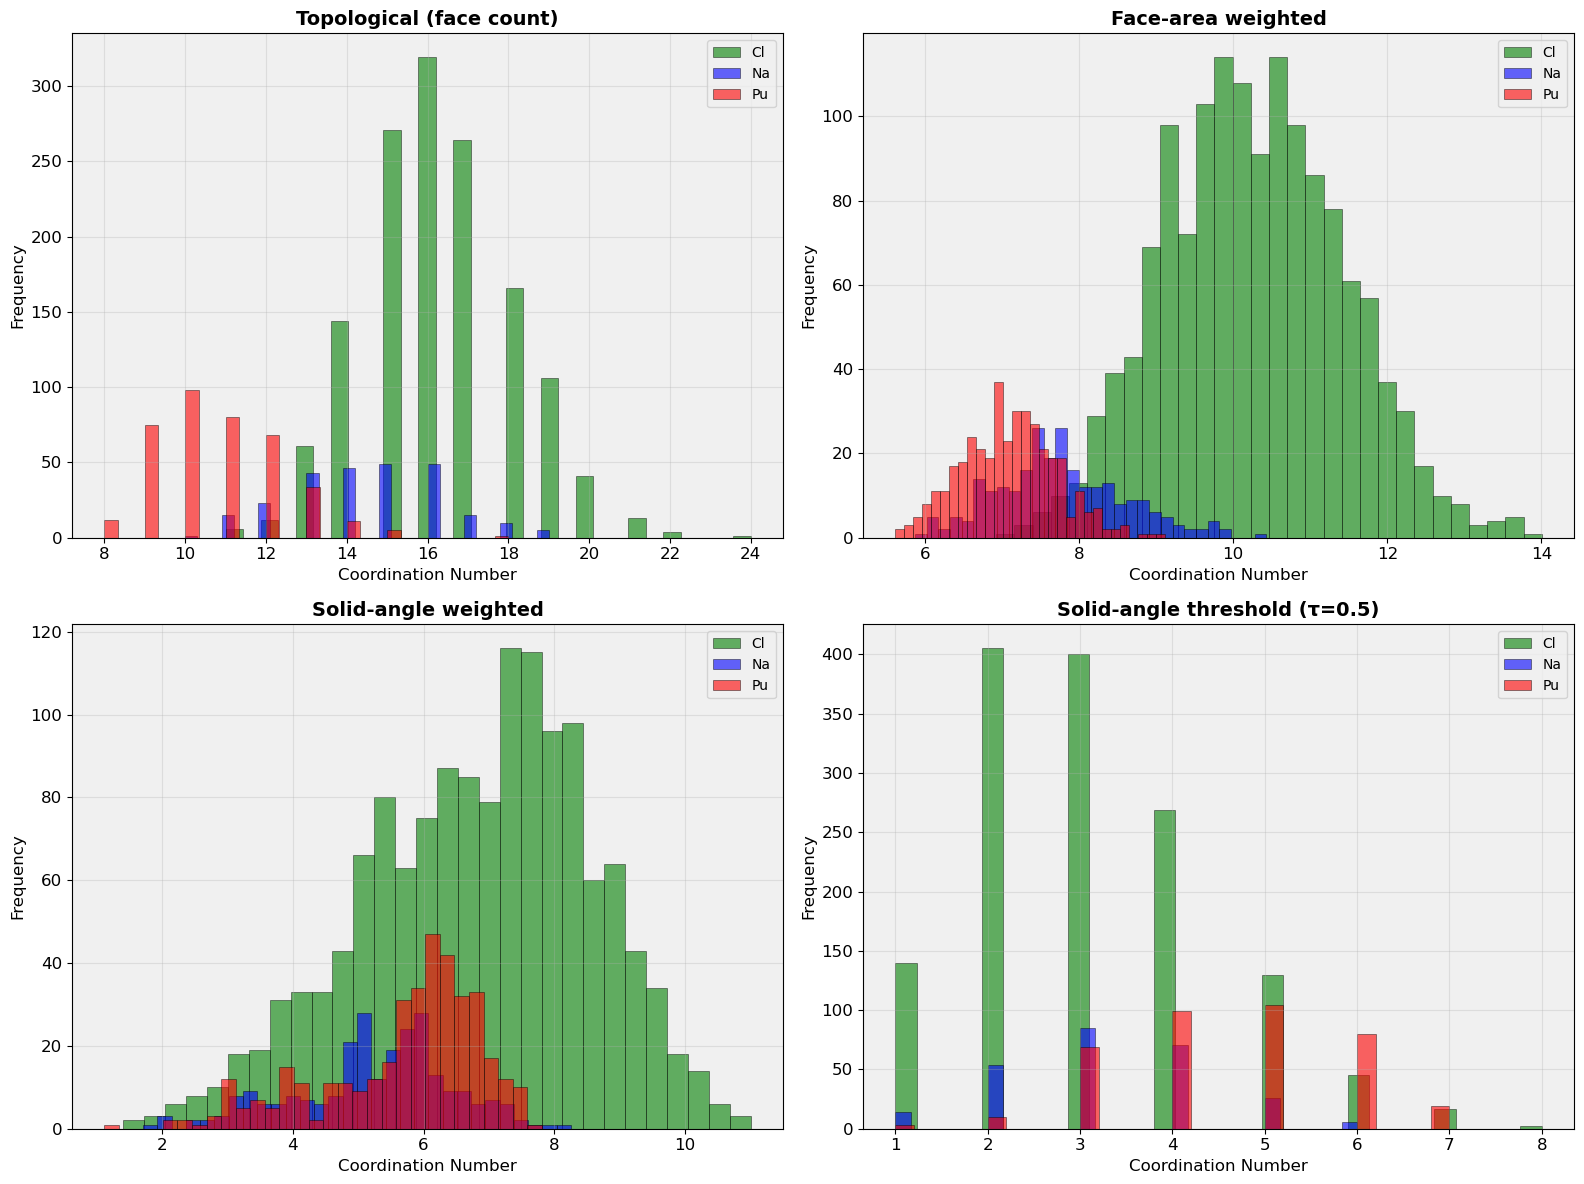


Plot saved as 'weighted_coordination_comparison.png'


In [64]:
# Visualization: Comparison of weighted coordination methods
print("=" * 60)
print("PLOTTING WEIGHTED COORDINATION NUMBER DISTRIBUTIONS")
print("=" * 60)

import matplotlib.pyplot as plt

# Create a comprehensive comparison plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors = {'Cl': 'green', 'Na': 'blue', 'Pu': 'red'}

for idx, (method_key, method_name) in enumerate(methods.items()):
    ax = axes[idx]
    
    # Get coordination data by species
    by_species = analyze_weighted_coordination_by_species(
        coord_results[method_key], 
        G_full_adaptive
    )
    
    # Plot histograms for each species
    for species in sorted(by_species.keys()):
        values = by_species[species]['values']
        color = colors.get(species, 'gray')
        
        ax.hist(values, bins=30, alpha=0.6, label=species, 
                color=color, edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel('Coordination Number', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(method_name, fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('weighted_coordination_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'weighted_coordination_comparison.png'")


In [65]:
# Weighted coordination analysis for Pu-only graph
print("=" * 60)
print("WEIGHTED COORDINATION ANALYSIS - Pu-Only Graph")
print("=" * 60)

# Build Pu-only Voronoi graph
print(f"\nBuilding Pu-only Voronoi graph (min_area={MIN_AREA_ADAPTIVE:.4f})")
G_pu_only = build_voronoi_graph_metals_only(
    sample_atoms, 
    min_area=MIN_AREA_ADAPTIVE, 
    metal_species=METAL_SPECIES
)

print(f"  Nodes: {G_pu_only.number_of_nodes()}")
print(f"  Edges: {G_pu_only.number_of_edges()}")

# Compute all coordination methods for Pu-only
print("\nComputing weighted coordination numbers for Pu-Pu interactions...")
coord_results_pu = analyze_voronoi_coordination_all_methods(
    G_pu_only, 
    positions=positions, 
    tau=0.5
)

print("\n" + "-" * 60)
print("Pu-Pu COORDINATION STATISTICS")
print("-" * 60)

for key, description in methods.items():
    cn_values = np.array(list(coord_results_pu[key].values()))
    
    # Filter out zeros for more meaningful statistics
    cn_nonzero = cn_values[cn_values > 0]
    
    print(f"\n{description}:")
    print(f"  All atoms - Mean: {np.mean(cn_values):.2f} ± {np.std(cn_values):.2f}")
    print(f"  All atoms - Range: [{np.min(cn_values):.2f}, {np.max(cn_values):.2f}]")
    
    if len(cn_nonzero) > 0:
        print(f"  Non-zero - Mean: {np.mean(cn_nonzero):.2f} ± {np.std(cn_nonzero):.2f}")
        print(f"  Non-zero - Range: [{np.min(cn_nonzero):.2f}, {np.max(cn_nonzero):.2f}]")
        print(f"  Atoms with neighbors: {len(cn_nonzero)} / {len(cn_values)} ({100*len(cn_nonzero)/len(cn_values):.1f}%)")

print("\n" + "=" * 60)


WEIGHTED COORDINATION ANALYSIS - Pu-Only Graph

Building Pu-only Voronoi graph (min_area=0.0000)
  Nodes: 384
  Edges: 3008

Computing weighted coordination numbers for Pu-Pu interactions...

------------------------------------------------------------
Pu-Pu COORDINATION STATISTICS
------------------------------------------------------------

Topological (face count):
  All atoms - Mean: 15.67 ± 2.19
  All atoms - Range: [9.00, 25.00]
  Non-zero - Mean: 15.67 ± 2.19
  Non-zero - Range: [9.00, 25.00]
  Atoms with neighbors: 384 / 384 (100.0%)

Face-area weighted:
  All atoms - Mean: 8.41 ± 1.32
  All atoms - Range: [5.94, 13.99]
  Non-zero - Mean: 8.41 ± 1.32
  Non-zero - Range: [5.94, 13.99]
  Atoms with neighbors: 384 / 384 (100.0%)

Solid-angle weighted:
  All atoms - Mean: 4.82 ± 1.41
  All atoms - Range: [1.41, 10.03]
  Non-zero - Mean: 4.82 ± 1.41
  Non-zero - Range: [1.41, 10.03]
  Atoms with neighbors: 384 / 384 (100.0%)

Solid-angle threshold (τ=0.5):
  All atoms - Mean: 2.57 ±

PLOTTING WEIGHTED COORDINATION NUMBER DISTRIBUTIONS


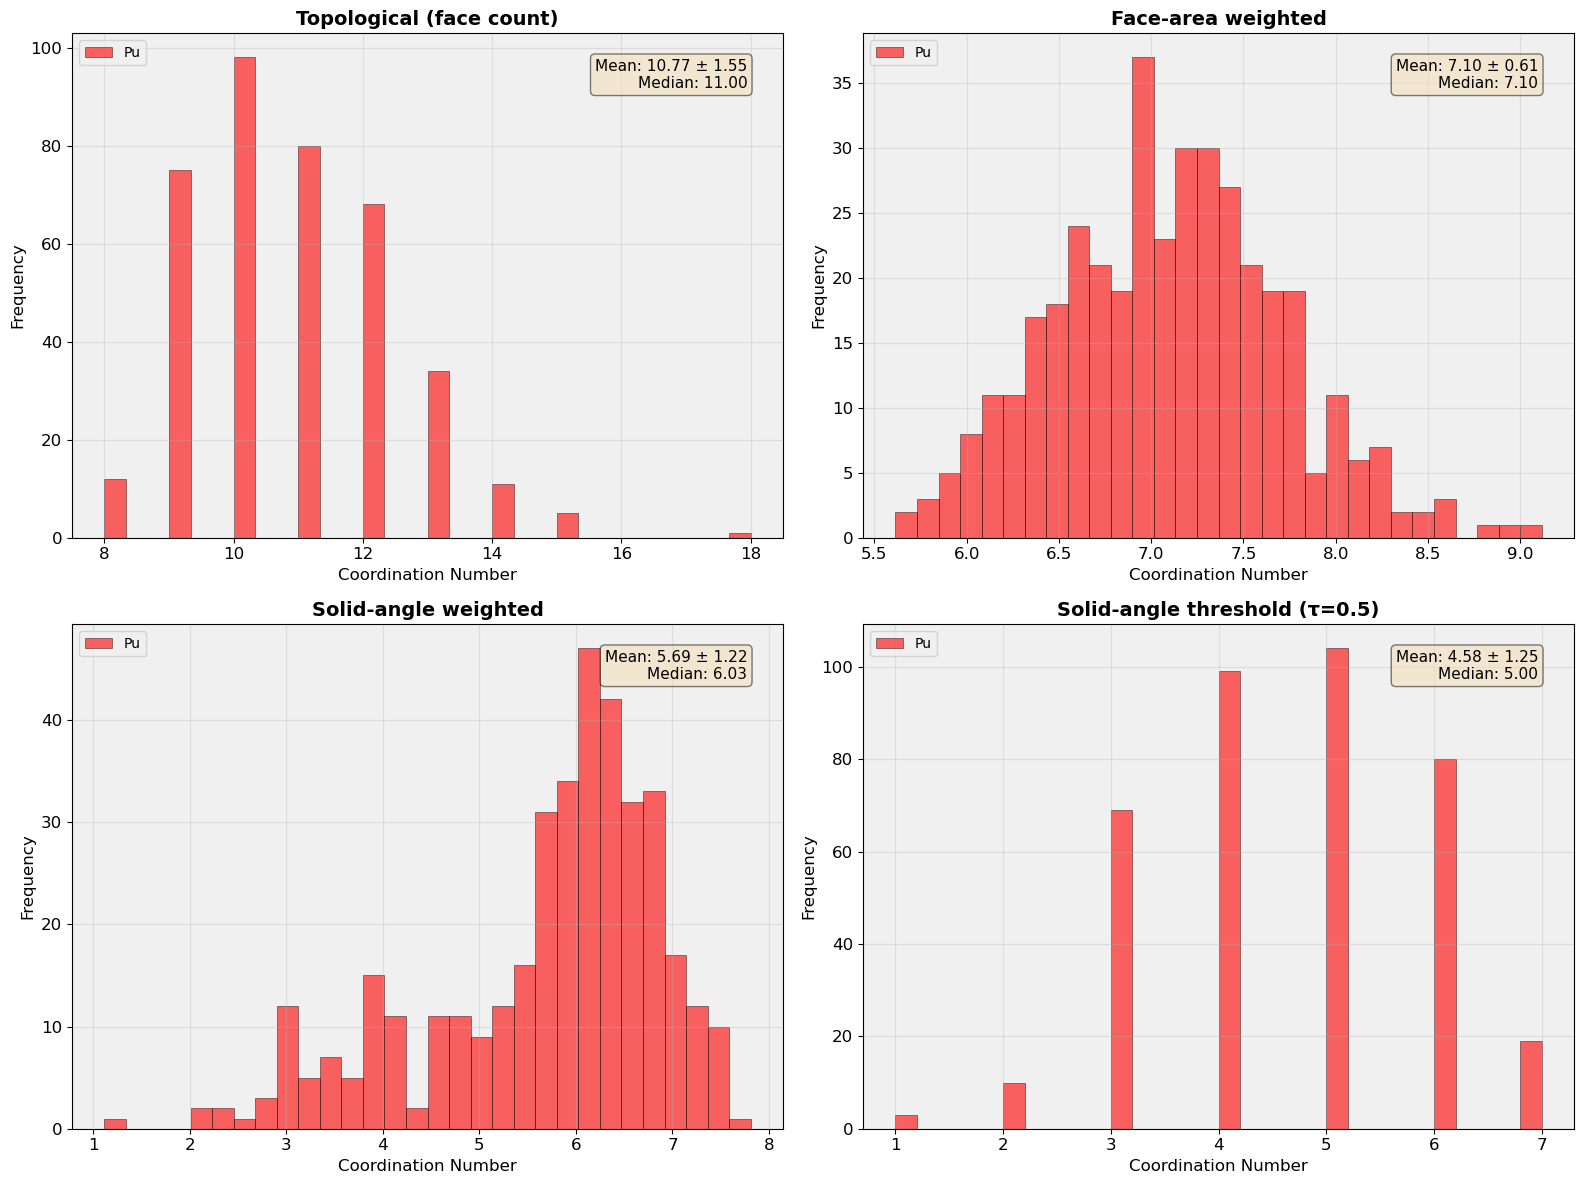


Plot saved as 'pu_weighted_coordination.png'


In [66]:
# Visualization: Comparison of weighted coordination methods
print("=" * 60)
print("PLOTTING WEIGHTED COORDINATION NUMBER DISTRIBUTIONS")
print("=" * 60)


# Create a comprehensive comparison plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors = {'Cl': 'green', 'Na': 'blue', 'Pu': 'red'}

for idx, (method_key, method_name) in enumerate(methods.items()):
    ax = axes[idx]


    
    # Get coordination data by species
    by_species = analyze_weighted_coordination_by_species(
        coord_results[method_key], 
        G_full_adaptive
    )
    
    # Plot histograms for each species
    for species in sorted(by_species.keys()):
        if species == "Pu":
                values = by_species[species]['values']
                mean_val = np.mean(values)
                std_val = np.std(values)
                median_val = np.median(values)
                color = colors.get(species, 'gray')
                
                ax.hist(values, bins=30, alpha=0.6, label=species, 
                        color=color, edgecolor='black', linewidth=0.5)
                textstr = f'Mean: {mean_val:.2f} ± {std_val:.2f}\nMedian: {median_val:.2f}'
                ax.text(0.95, 0.95, textstr, transform=ax.transAxes,
                        fontsize=11, verticalalignment='top', horizontalalignment='right',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Coordination Number', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(method_name, fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('pu_weighted_coordination.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'pu_weighted_coordination.png'")


In [69]:
# by_species2

CORRELATION BETWEEN DIFFERENT COORDINATION METHODS


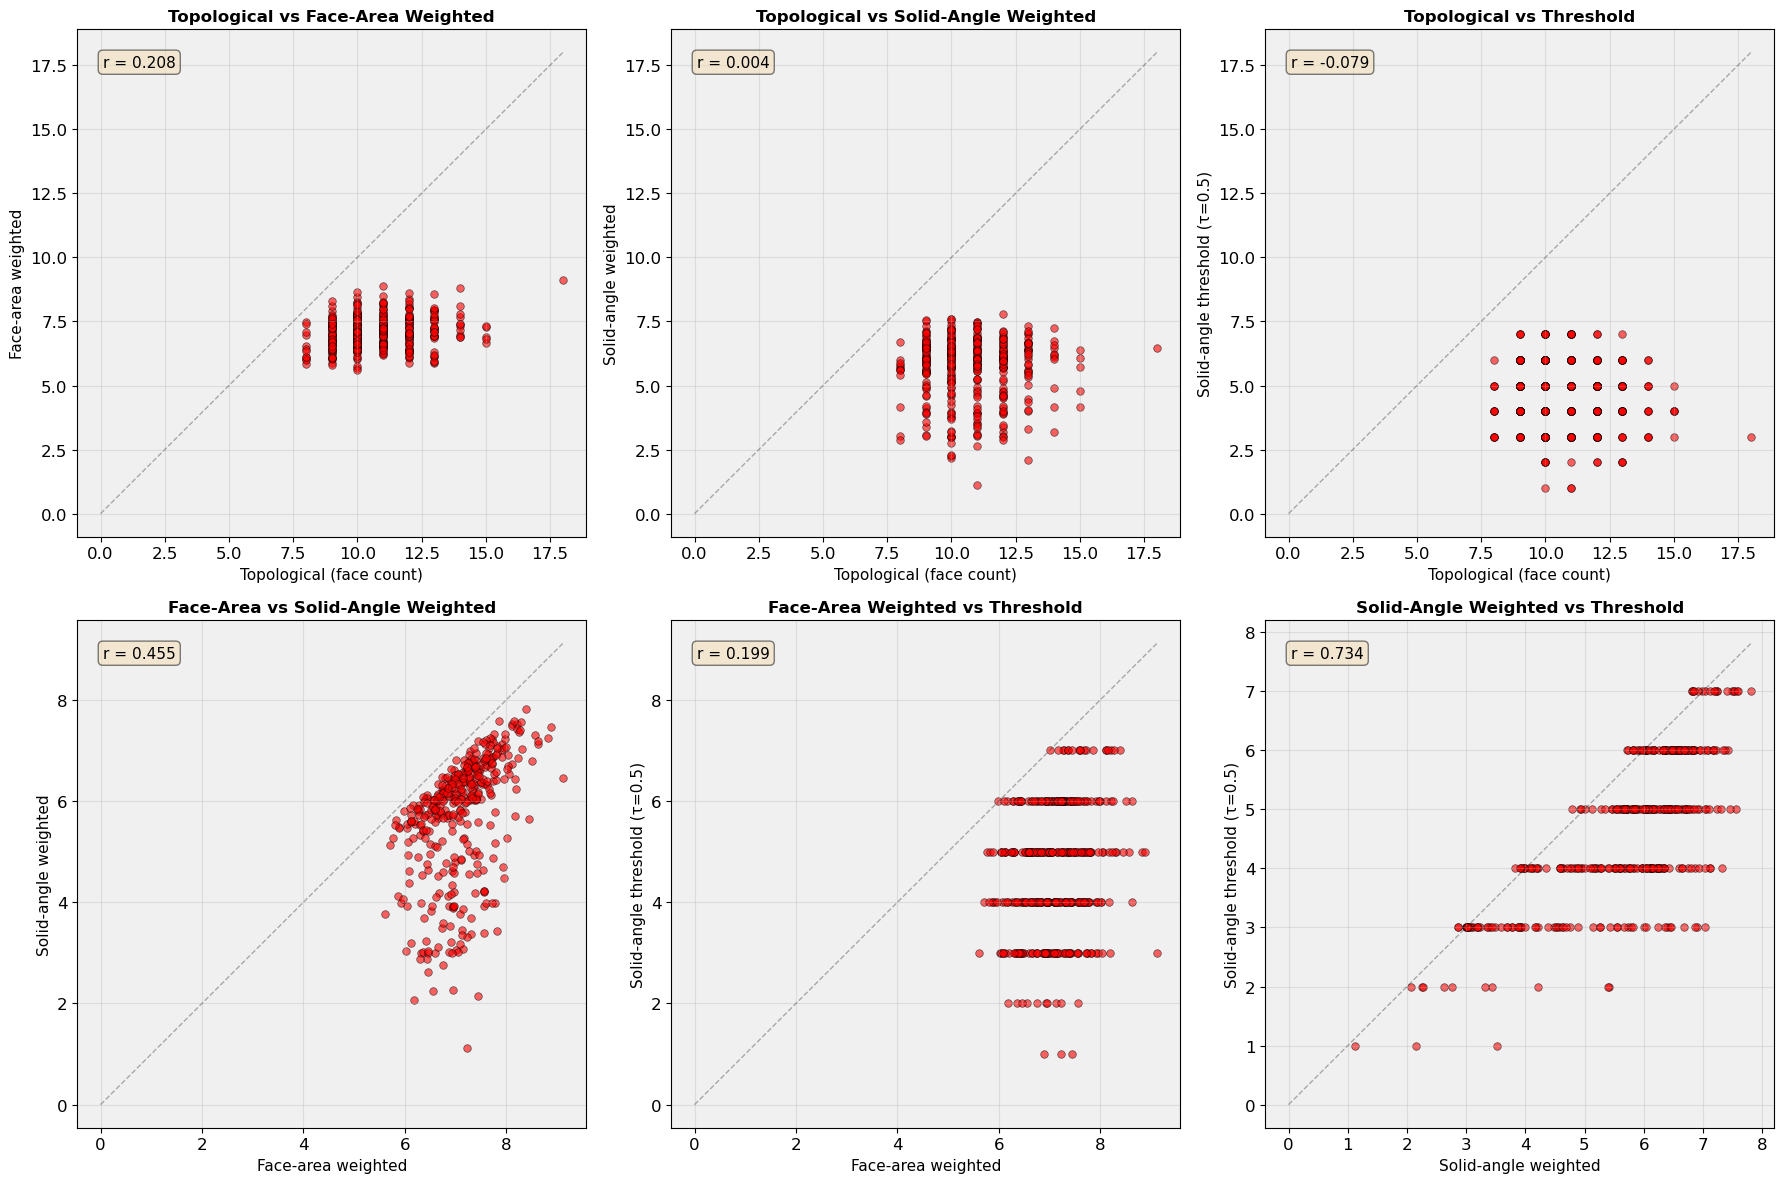


Plot saved as 'coordination_method_comparison.png'


In [67]:
# Method comparison: scatter plots showing correlation between methods
print("=" * 60)
print("CORRELATION BETWEEN DIFFERENT COORDINATION METHODS")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Compare pairs of methods
comparisons = [
    ('CN_faces', 'CN_A', 'Topological vs Face-Area Weighted'),
    ('CN_faces', 'CN_Ω', 'Topological vs Solid-Angle Weighted'),
    ('CN_faces', 'CN_threshold', 'Topological vs Threshold'),
    ('CN_A', 'CN_Ω', 'Face-Area vs Solid-Angle Weighted'),
    ('CN_A', 'CN_threshold', 'Face-Area Weighted vs Threshold'),
    ('CN_Ω', 'CN_threshold', 'Solid-Angle Weighted vs Threshold'),
]

# Use Pu-only data for better visualization
for idx, (method1, method2, title) in enumerate(comparisons):
    ax = axes[idx]

    # Get coordination data by species
    by_species1 = analyze_weighted_coordination_by_species(
        coord_results[method1], 
        G_full_adaptive
    )
    by_species2 = analyze_weighted_coordination_by_species(
        coord_results[method2], 
        G_full_adaptive
    )
    
    # Plot histograms for each species
    for species in sorted(by_species.keys()):
        if species == "Pu":
                vals1 = np.array(list(by_species1[species]['values']))
                vals2 = np.array(list(by_species2[species]['values']))  
    
    
    # Scatter plot
    ax.scatter(vals1, vals2, alpha=0.6, s=30, color='red', edgecolors='black', linewidth=0.5)
    
    # Add diagonal line for reference
    max_val = max(vals1.max(), vals2.max())
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=1)
    
    # Calculate correlation
    if len(vals1) > 1 and np.std(vals1) > 0 and np.std(vals2) > 0:
        correlation = np.corrcoef(vals1, vals2)[0, 1]
        ax.text(0.05, 0.95, f'r = {correlation:.3f}', 
                transform=ax.transAxes, fontsize=11,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel(methods[method1], fontsize=11)
    ax.set_ylabel(methods[method2], fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('coordination_method_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'coordination_method_comparison.png'")


TEMPORAL ANALYSIS OF WEIGHTED COORDINATION NUMBERS

Analyzing 20 frames (sampling every 25 frames)

Processing frames...
  Frame 1/20...
  Frame 6/20...
  Frame 11/20...
  Frame 16/20...

Temporal analysis complete!


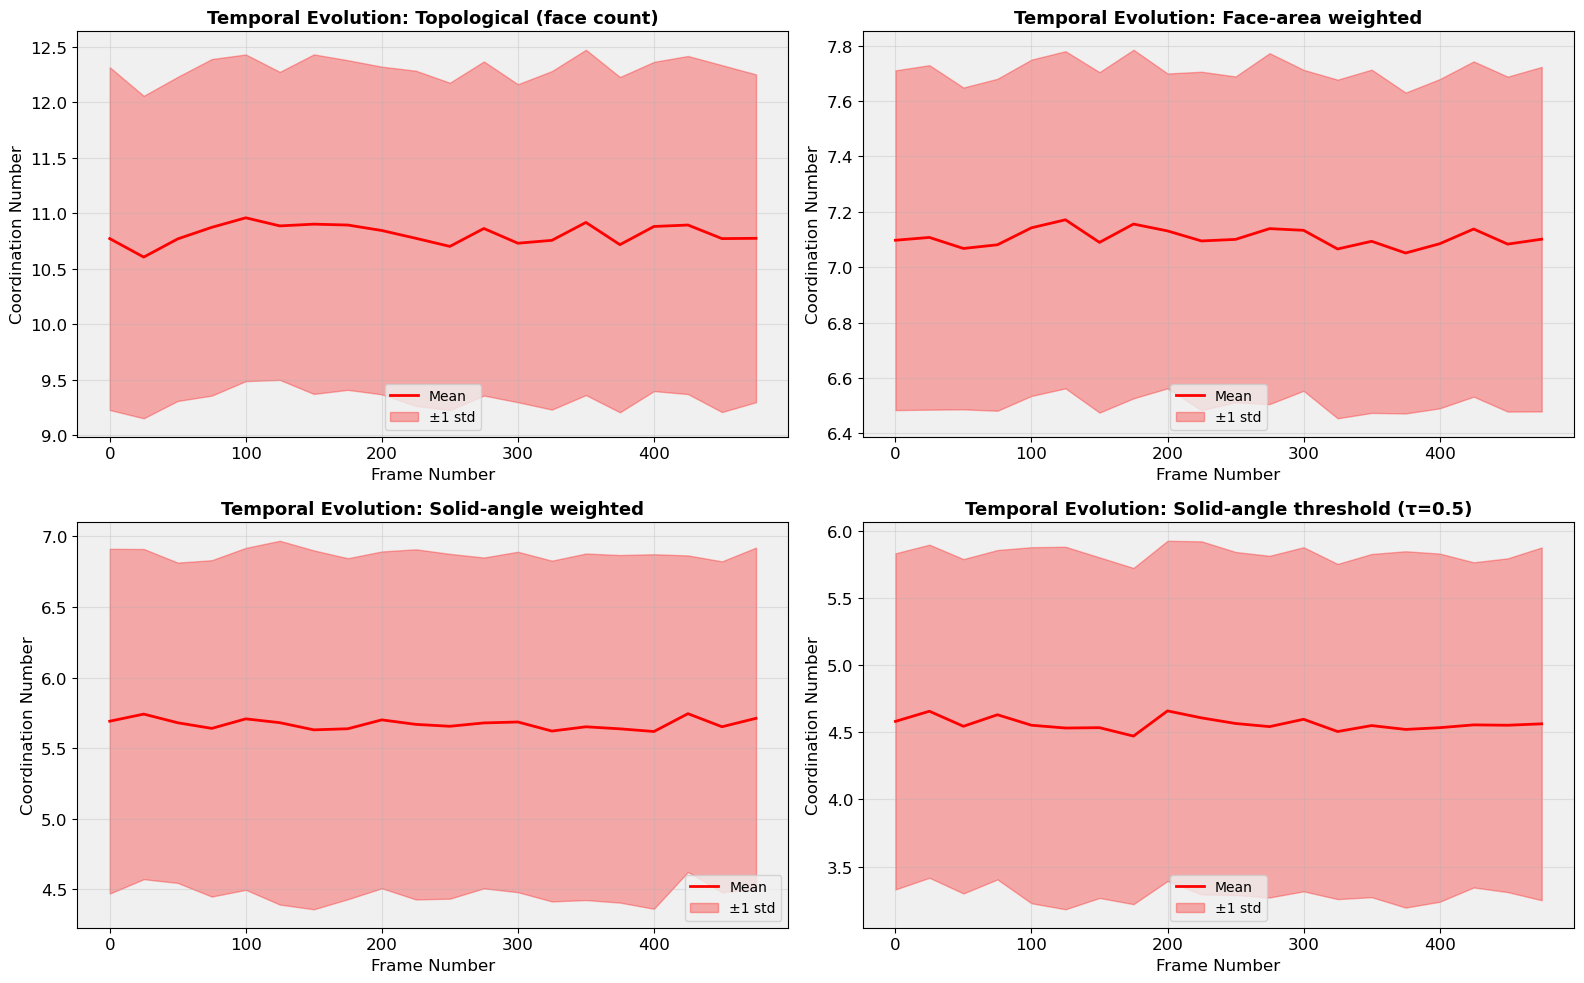


Plot saved as 'temporal_weighted_coordination.png'



In [79]:
# Temporal evolution of weighted coordination numbers
print("=" * 60)
print("TEMPORAL ANALYSIS OF WEIGHTED COORDINATION NUMBERS")
print("=" * 60)

# Sample frames for temporal analysis (to avoid computational cost)
sample_every = 25  # Sample every 25th frame
sampled_frames = atoms_list[::sample_every]
print(f"\nAnalyzing {len(sampled_frames)} frames (sampling every {sample_every} frames)")

# Store temporal data
temporal_weighted_cn = {
    'frames': [],
    'CN_faces_mean': [], 'CN_faces_std': [],
    'CN_A_mean': [], 'CN_A_std': [],
    'CN_Ω_mean': [], 'CN_Ω_std': [],
    'CN_threshold_mean': [], 'CN_threshold_std': []
}

print("\nProcessing frames...")
for frame_idx, frame in enumerate(sampled_frames):
    if frame_idx % 5 == 0:
        print(f"  Frame {frame_idx+1}/{len(sampled_frames)}...")
    
    # Build Pu-only graph for this frame
    G_frame = build_voronoi_graph(
        frame, 
        min_area=MIN_AREA_ADAPTIVE
    )
    
    # Get positions
    pos_frame = frame.get_positions()
    
    # Compute coordination for this frame
    coord_frame = analyze_voronoi_coordination_all_methods(
        G_frame, 
        positions=pos_frame, 
        tau=0.5
    )


    
    # Store statistics
    temporal_weighted_cn['frames'].append(frame_idx * sample_every)
    
    for method_key in ['CN_faces', 'CN_A', 'CN_Ω', 'CN_threshold']:
        by_species_method = analyze_weighted_coordination_by_species(
            coord_frame[method_key], 
            G_frame
        )
        temporal_weighted_cn[f'{method_key}_mean'].append(by_species_method['Pu']['statistics']['mean'])
        temporal_weighted_cn[f'{method_key}_std'].append(by_species_method['Pu']['statistics']['std'])

print("\nTemporal analysis complete!")

# Plot temporal evolution
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

method_keys = ['CN_faces', 'CN_A', 'CN_Ω', 'CN_threshold']
for idx, method_key in enumerate(method_keys):
    ax = axes[idx]
    
    frames = temporal_weighted_cn['frames']
    means = temporal_weighted_cn[f'{method_key}_mean']
    stds = temporal_weighted_cn[f'{method_key}_std']
    
    # Plot mean with error bands
    ax.plot(frames, means, 'r-', linewidth=2, label='Mean')
    ax.fill_between(frames, 
                     np.array(means) - np.array(stds), 
                     np.array(means) + np.array(stds),
                     alpha=0.3, color='red', label='±1 std')
    
    ax.set_xlabel('Frame Number', fontsize=12)
    ax.set_ylabel('Coordination Number', fontsize=12)
    ax.set_title(f'Temporal Evolution: {methods[method_key]}', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('temporal_weighted_coordination.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'temporal_weighted_coordination.png'")
print("\n" + "=" * 60)


In [ ]:
# ============================================================================
# WEIGHTED VORONOI COORDINATION NUMBER ANALYSIS - SUMMARY
# ============================================================================

"""
This notebook now includes comprehensive weighted Voronoi coordination number
analysis using functions from voronoi/voronoi_coordination.py.

## Available Methods

### 1. Topological Coordination Number (CN_faces)
- Simple count of Voronoi faces
- CN = number of neighbors
- Most basic method, does not consider face size

### 2. Face-Area Weighted CN (CN_A)
- Weights neighbors by Voronoi face area
- Formula: CN_A = (Σ A_i)² / Σ A_i²
- Larger faces contribute more to the coordination number
- Good for liquids and amorphous systems

### 3. Solid-Angle Weighted CN (CN_Ω)
- Weights neighbors by solid angle (Ω = A/r²)
- Formula: CN_Ω = (Σ Ω_i)² / Σ Ω_i²
- Considers both face area and distance
- Best for disordered systems with varying neighbor distances

### 4. Threshold-Based CN (O'Keeffe/VoronoiNN)
- Counts neighbors above a threshold
- Threshold: w_i ≥ τ × max(w_j)
- Default τ = 0.5
- Good for identifying "significant" neighbors

### 5. CrystalNN Weights
- Combined solid-angle and face-area scheme
- Weight: w_i = Ω_i² / A_i
- Can be extended with distance and chemical weighting

## Key Functions Used

```python
# Single-frame analysis
coord_results = analyze_voronoi_coordination_all_methods(
    voronoi_graph,
    positions=atom_positions,
    tau=0.5
)

# Organize by species
by_species = analyze_weighted_coordination_by_species(
    coord_results['CN_A'],
    voronoi_graph
)

# Compute histogram data
hist_data = compute_coordination_histogram_data(
    coord_results['CN_Ω'],
    voronoi_graph,
    bins=30
)
```

## Output Files Generated

1. `weighted_coordination_comparison.png` - Comparison of all methods (all atoms)
2. `pu_weighted_coordination.png` - Pu-only coordination distributions
3. `coordination_method_comparison.png` - Correlation between methods
4. `temporal_weighted_coordination.png` - Time evolution of coordination

## References

- O'Keeffe, M. (1979). Solid-angle thresholding in Voronoi tessellation
- Okabe et al. (2000). Spatial Tessellations: Concepts and Applications
- CrystalNN from Materials Project (pymatgen)
- VoronoiNN analysis methods

## Tips for Usage

- Use CN_A for simple liquid/amorphous analysis
- Use CN_Ω when distance variations are important
- Use CN_threshold for identifying coordination shells
- Compare methods to understand neighbor importance
- Adjust MIN_AREA threshold to control percolation
"""

print("=" * 70)
print("WEIGHTED VORONOI COORDINATION ANALYSIS - COMPLETE")
print("=" * 70)
print("\nThis notebook now includes:")
print("  ✓ Topological coordination numbers")
print("  ✓ Face-area weighted coordination numbers")
print("  ✓ Solid-angle weighted coordination numbers")
print("  ✓ Threshold-based coordination analysis")
print("  ✓ CrystalNN weighting scheme")
print("  ✓ Species-specific analysis")
print("  ✓ Temporal evolution tracking")
print("  ✓ Comprehensive visualization plots")
print("\nAll analysis complete! Check the generated PNG files for results.")
print("=" * 70)


WEIGHTED VORONOI COORDINATION ANALYSIS - COMPLETE

This notebook now includes:
  ✓ Topological coordination numbers
  ✓ Face-area weighted coordination numbers
  ✓ Solid-angle weighted coordination numbers
  ✓ Threshold-based coordination analysis
  ✓ CrystalNN weighting scheme
  ✓ Species-specific analysis
  ✓ Temporal evolution tracking
  ✓ Comprehensive visualization plots

All analysis complete! Check the generated PNG files for results.
